In [4]:
import os
print(os.getcwd())

/home/onyxia/work/les_arbres


In [5]:
import sys
sys.path.append('./src')
import utils
import pandas as pd
import s3fs
import geopandas as gpd

arbres = pd.read_csv("https://www.data.gouv.fr/api/1/datasets/r/60433484-f30e-44ef-a362-e5553a9b7a42", sep = ";")

fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})

MY_BUCKET = "raphcrre"
PATH_IRIS = f"{MY_BUCKET}/diffusion/projet_arbres/iris.gpkg"

with fs.open(PATH_IRIS, 'rb') as f:
    iris_france = gpd.read_file(f)

iris = iris_france[iris_france['code_insee'].astype(str).str.startswith('75')].copy()

df_arbres = utils.jointure_arbres_iris(arbres, iris)

df_arbres

/opt/python/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsimem/pyogrio_3c405c46f26b4fe88c44aaad4c422faf has GPKG application_id, but non conformant file extension
  return ogr_read(


,IDBASE,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,COMPLEMENT ADRESSE,LIEU / ADRESSE,IDEMPLACEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,...,lon,geometry,index_right,cleabs,code_insee,nom_commune,iris,code_iris,nom_iris,type_iris
0,267615,Arbre,Alignement,PARIS 1ER ARRDT,4 f,QUAI FRANCOIS MITTERRAND,000101033,Platane,Platanus,x hispanica,...,2.336197,POINT (651297.47 6862352.805),1010.0,IRIS____0000000751010199,75101,Paris 1er Arrondissement,0199,751010199,Seine et Berges,D
1,2001356,Arbre,Alignement,BOIS DE BOULOGNE,Candélabre n°7281,ALLEE DE LA REINE MARGUERITE,001202097,Marronnier,Aesculus,hippocastanum,...,2.254016,POINT (645281.981 6863873.891),1131.0,IRIS____0000000751166277,75116,Paris 16e Arrondissement,6277,751166277,Bois de Boulogne 2,D
2,2015583,Arbre,Jardin,BOIS DE VINCENNES,NaN,PARC FLORAL DE PARIS / ROUTE DE LA PYRAMIDE,02910005,Magnolia,Magnolia,grandiflora,...,2.443908,POINT (659182.59 6859822.43),1117.0,IRIS____0000000751124577,75112,Paris 12e Arrondissement,4577,751124577,Bois de Vincennes 1,D
3,2021315,Arbre,DASCO,PARIS 20E ARRDT,NaN,ECOLE MATERNELLE / 20 RUE DES CENDRIERS,063902002,Poirier à fruits,Pyrus,communis,...,2.386775,POINT (655013.244 6862971.921),15545.0,IRIS____0000000751207906,75120,Paris 20e Arrondissement,7906,751207906,Père Lachaise 6,H
4,2054405,Arbre,Alignement,PARIS 13E ARRDT,NaN,PLACE NATIONALE,000304001,Tilleul,Tilia,x europaea,...,2.365357,POINT (653410.164 6859015.797),15037.0,IRIS____0000000751135030,75113,Paris 13e Arrondissement,5030,751135030,Gare 30,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217747,283255,Arbre,Alignement,PARIS 19E ARRDT,NaN,PLACE DE JOINVILLE,000101006,Platane,Platanus,x hispanica,...,2.380304,POINT (654559.854 6865691.787),15455.0,IRIS____0000000751197314,75119,Paris 19e Arrondissement,7314,751197314,Villette 14,H
217748,2024286,Arbre,Jardin,BOIS DE VINCENNES,L-08,ARBORETUM DE PARIS / 50 ROUTE DE LA PYRAMIDE,05-719480719,Cèdre,Cedrus,atlantica,...,2.457343,POINT (660156.615 6858055.064),1118.0,IRIS____0000000751124677,75112,Paris 12e Arrondissement,4677,751124677,Bois de Vincennes 2,D
217749,261246,Arbre,Alignement,PARIS 17E ARRDT,NaN,RUE CURNONSKY,000202001,Erable,Acer,platanoides,...,2.297165,POINT (648465.006 6865887.484),15334.0,IRIS____0000000751176616,75117,Paris 17e Arrondissement,6616,751176616,Plaine Monceau 16,H
217750,232032,Arbre,Alignement,PARIS 19E ARRDT,NaN,RUE DE BELLEVILLE,000103011,Sophora,Styphnolobium,japonicum,...,2.394283,POINT (655572.757 6864098.942),15474.0,IRIS____0000000751197505,75119,Paris 19e Arrondissement,7505,751197505,Amérique 5,H


/tmp/ipykernel_10490/3304543620.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


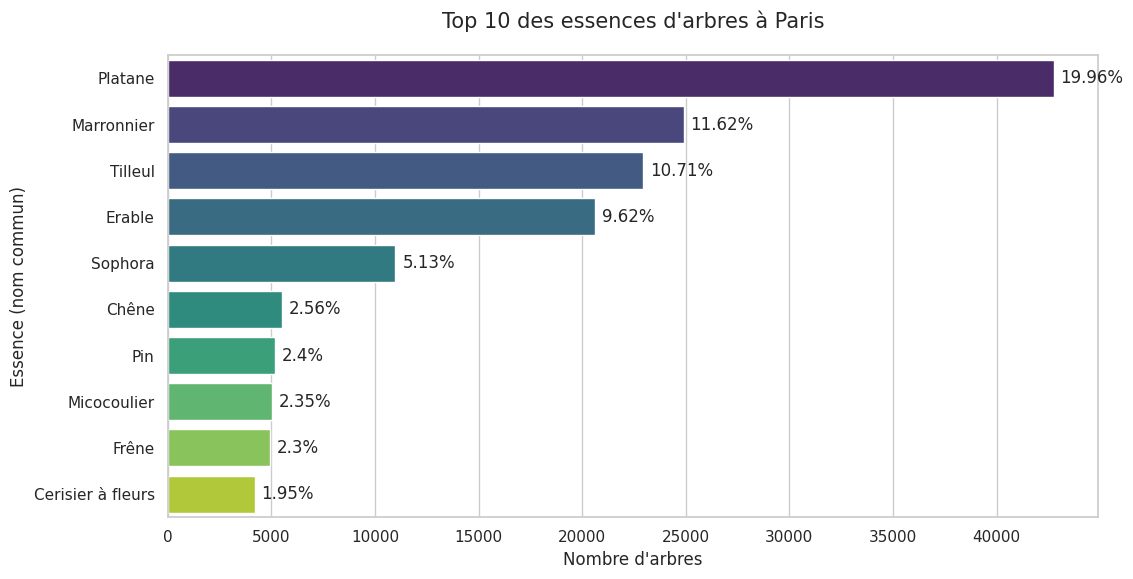

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import utils3

# 1. Récupération des données via ton module
df_top = utils3.get_top_species(arbres, column_name = "LIBELLE FRANCAIS")

# 2. Création du graphique
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_top, 
    x='Nombre', 
    y='Espece', 
    palette='viridis'
)

# 3. Cosmétique (pour que ce soit "qualitatif")
plt.title('Top 10 des essences d\'arbres à Paris', fontsize=15, pad=20)
plt.xlabel('Nombre d\'arbres')
plt.ylabel('Essence (nom commun)')

# Ajout des pourcentages au bout des barres
for i, p in enumerate(ax.patches):
    percentage = f"{df_top['Pourcentage'].iloc[i]}%"
    ax.annotate(percentage, (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.show()